# Notebook 01 - Data Audit
## Compound Crisis Cascade: Kenya

**Purpose:**  
This notebook answers four questions:
1. What is the shape and structure of each dataset?
2. What is the temporal coverage - and where do datasets overlap in time?
3. What is the geographic coverage - and which counties appear across all datasets?
4. Where are the gaps, and how do we handle them transparently?

**Datasets:**
- `hdx_hapi_rainfall_ken.csv` - WFP rainfall and anomaly data
- `hdx_hapi_food_price_ken.csv` - WFP food market prices
- `hdx_hapi_conflict_event_ken.csv` - ACLED conflict events
- `hdx_hapi_food_security_ken.csv` - IPC food security phases
- `hdx_hapi_population_ken.csv` - UNFPA baseline population
- `hdx_hapi_poverty_rate_ken.csv` - Oxford OPHI poverty rates

**Source:** HDX Humanitarian API — https://data.humdata.org/dataset/hdx-hapi-ken  

## 0.0 Setup - Libraries and Configuration

In [1]:
# Standard library imports
import os
import warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Settings
warnings.filterwarnings('ignore')          # Suppress minor pandas warnings
pd.set_option('display.max_columns', 30)   # Show all columns in previews
pd.set_option('display.float_format', '{:.2f}'.format)  # Clean float display

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Project colour palette
# Consistent colours used across all notebooks
COLOURS = {
    'rainfall':     '#2166ac',   # Blue  — water/climate
    'food_price':   '#d6604d',   # Red   — price stress
    'conflict':     '#1a1a1a',   # Near-black — severity
    'food_security':'#f4a582',   # Salmon — hunger
    'poverty':      '#762a83',   # Purple — structural vulnerability
    'highlight':    '#fdae61',   # Amber  — callout
    'neutral':      '#878787',   # Grey   — background elements
}

print("Libraries loaded successfully.")
print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")

Libraries loaded successfully.
pandas  1.4.4
numpy   1.24.4


## 1. Load Datasets

In [2]:
#build a folder path
RAW = os.path.join('..', 'data', 'raw')

In [3]:
# Load all six datasets
# parse_dates converts reference period columns from string to datetime,
# which is essential for time-series analysis.
DATE_COLS = ['reference_period_start', 'reference_period_end']

def load_dataset(name):
    return pd.read_csv(
        os.path.join(RAW, f'hdx_hapi_{name}_ken.csv'),
        parse_dates=DATE_COLS
    )

In [4]:
#load datasets
datasets = [
    'rainfall',
    'food_price',
    'conflict_event',
    'food_security',
    'population',
    'poverty_rate'
]

DATASETS = {name: load_dataset(name) for name in datasets}

In [5]:
DATASETS['food_security'].head()

,location_code,has_hrp,in_gho,provider_admin1_name,provider_admin2_name,admin1_code,admin1_name,admin2_code,admin2_name,admin_level,ipc_phase,ipc_type,population_in_phase,population_fraction_in_phase,reference_period_start,reference_period_end
0,KEN,False,True,NaN,NaN,NaN,NaN,NaN,NaN,0,all,current,16617000,1.00,2025-07-01,2025-09-30
1,KEN,False,True,NaN,NaN,NaN,NaN,NaN,NaN,0,3+,current,1760950,0.11,2025-07-01,2025-09-30
2,KEN,False,True,NaN,NaN,NaN,NaN,NaN,NaN,0,1,current,8426900,0.51,2025-07-01,2025-09-30
3,KEN,False,True,NaN,NaN,NaN,NaN,NaN,NaN,0,2,current,6429150,0.39,2025-07-01,2025-09-30
4,KEN,False,True,NaN,NaN,NaN,NaN,NaN,NaN,0,3,current,1581650,0.10,2025-07-01,2025-09-30


## 2. Dataset Shapes and Structure

We first confirm the row count, column count, and data types for each dataset.  
This helps catch truncated downloads and encoding issues.

In [6]:
# Summary table: rows, columns, date range 
summary_rows = []

for name, df in DATASETS.items():
    summary_rows.append({
        'Dataset':    name,
        'Rows':       f"{len(df):,}",
        'Columns':    len(df.columns),
        'Date Start': df['reference_period_start'].min().date(),
        'Date End':   df['reference_period_end'].max().date(),
        'Null Cells': df.isnull().sum().sum(),
    })

summary_df = pd.DataFrame(summary_rows)
print("Dataset Overview")
print(" ")
print(summary_df.to_string(index=False))

Dataset Overview
 
       Dataset   Rows  Columns Date Start   Date End  Null Cells
      rainfall 11,460       20 2022-01-01 2026-02-20       22188
    food_price 14,972       22 2017-01-15 2025-12-14       30166
conflict_event 16,150       13 1997-01-18 2026-10-04        5122
 food_security  4,830       16 2019-07-01 2026-01-31       15848
    population  3,168       17 2019-01-01 2019-12-31        9702
  poverty_rate     73       14 2008-01-01 2022-12-31          39


In [7]:
# Inspect each dataset individually
# Running .info() shows column names, non-null counts, and dtypes.
# This tells us immediately if date parsing worked and which columns are empty.

for name, df in DATASETS.items():
    print(f"\n{' '}")
    print(f" {name.upper()}")
    print(f"{' '}")
    df.info(verbose=True, show_counts=True)


 
 RAINFALL
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11460 entries, 0 to 11459
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   location_code               11460 non-null  object        
 1   has_hrp                     11460 non-null  bool          
 2   in_gho                      11460 non-null  bool          
 3   provider_admin1_name        11460 non-null  object        
 4   provider_admin2_name        7884 non-null   object        
 5   admin1_code                 11460 non-null  object        
 6   admin1_name                 11460 non-null  object        
 7   admin2_code                 7884 non-null   object        
 8   admin2_name                 7884 non-null   object        
 9   admin_level                 11460 non-null  int64         
 10  provider_admin1_code        3576 non-null   float64       
 11  provider_admin2_code        7884 non-nu

## 3. Null Value Audit

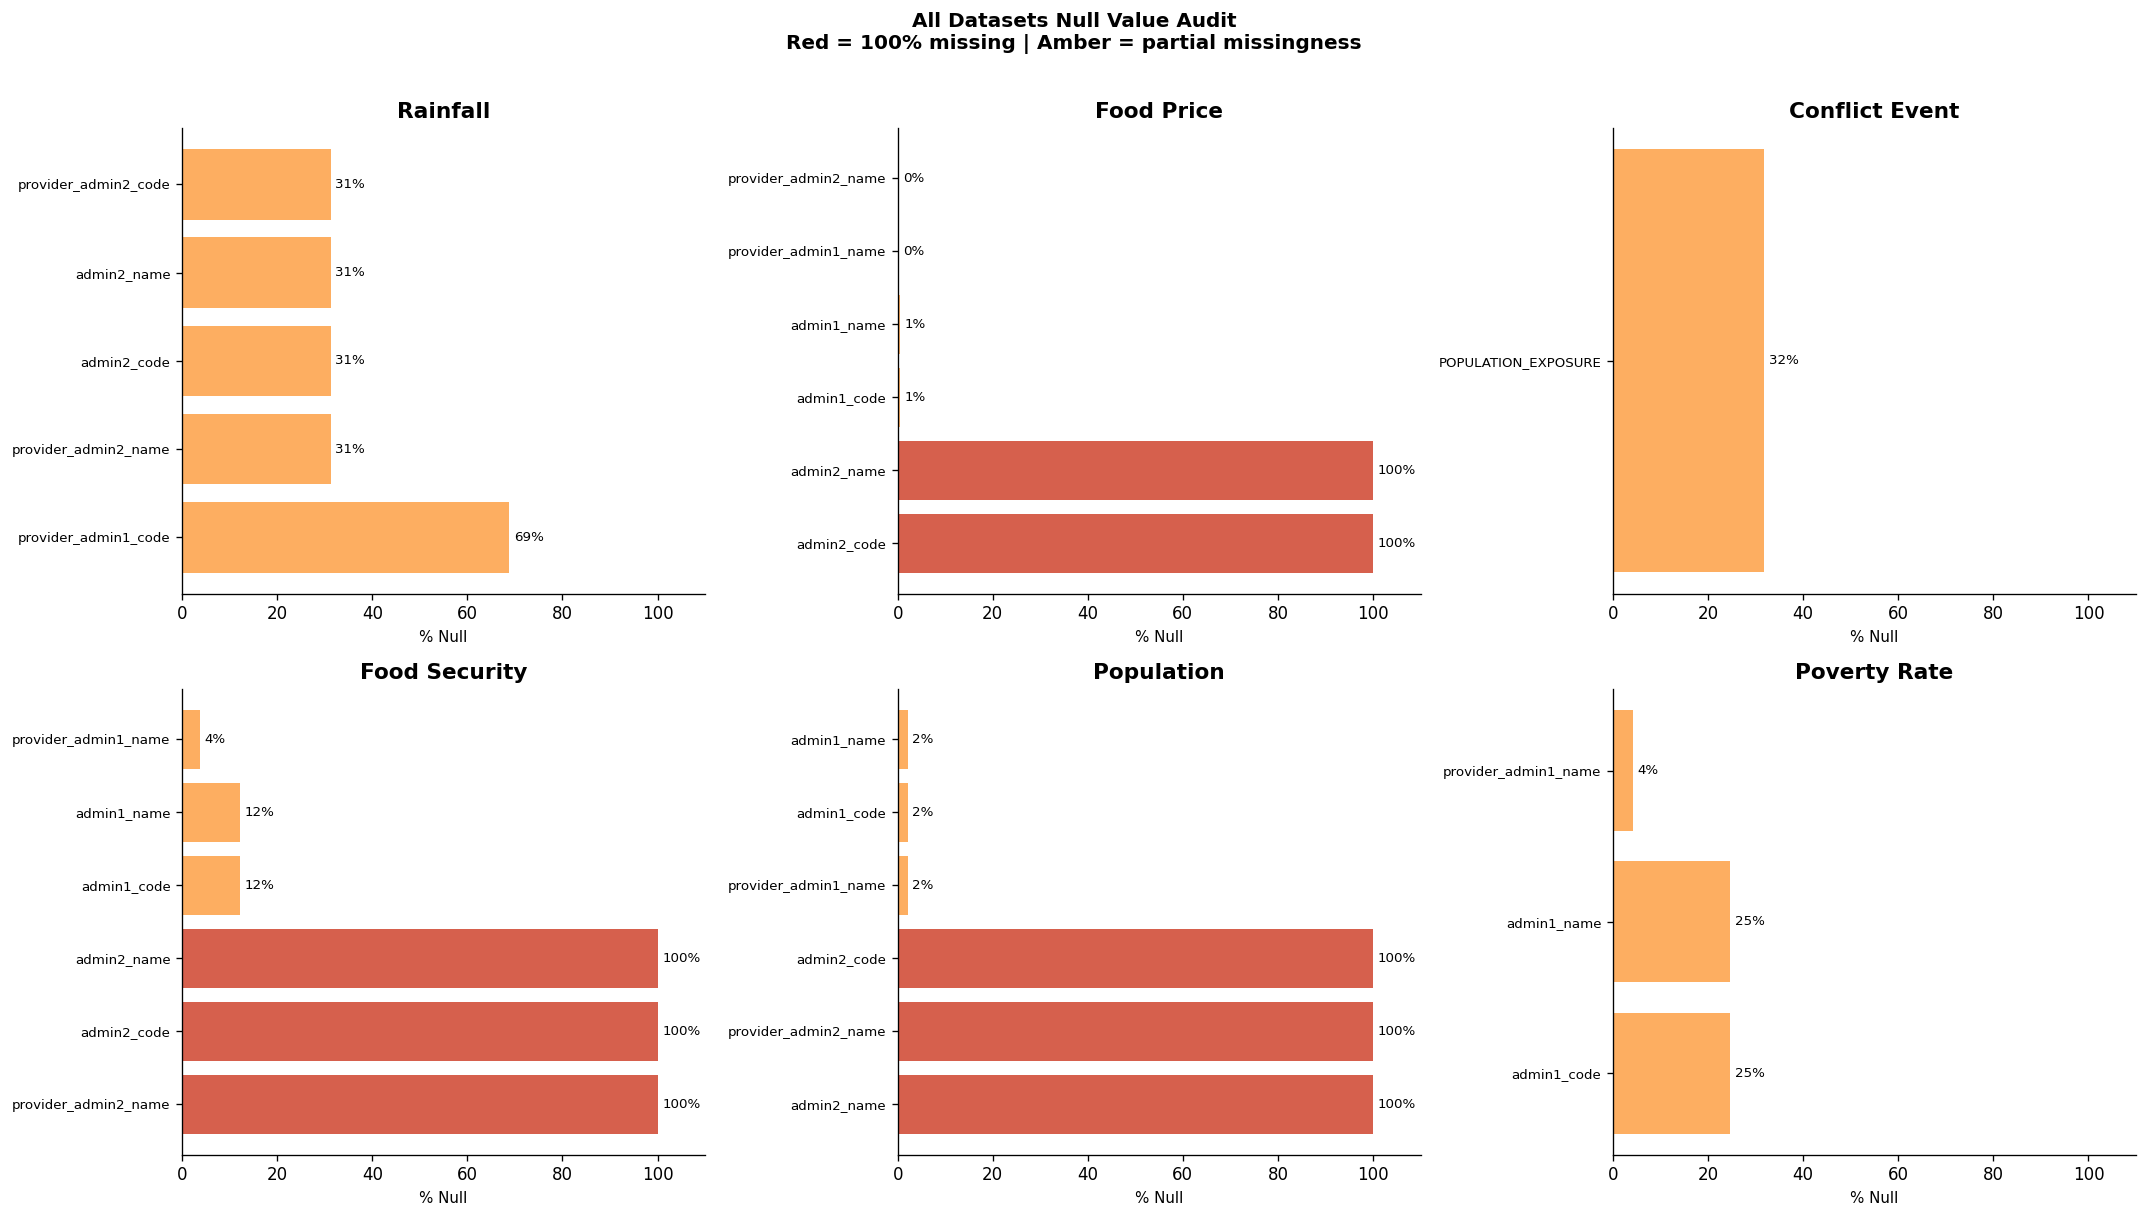

In [8]:
# Visualise missingness as a percentage per column per dataset using a heatmap
# Columns with 100% null are structurally missing hence not a cleaning problem.

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, df) in enumerate(DATASETS.items()):
    ax = axes[idx]

    # Calculate null percentage per column
    null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    null_pct = null_pct[null_pct > 0]  # Only show columns with any nulls

    if null_pct.empty:
        ax.text(0.5, 0.5, 'No nulls', ha='center', va='center',
                fontsize=14, color=COLOURS['neutral'])
        ax.set_title(name.replace('_', ' ').title(), fontweight='bold')
        ax.axis('off')
        continue

    # Colour bars: red if 100% null (structural), amber if partial
    bar_colours = [
        COLOURS['food_price'] if v == 100 else COLOURS['highlight']
        for v in null_pct.values
    ]

    bars = ax.barh(null_pct.index, null_pct.values, color=bar_colours)
    ax.set_xlim(0, 110)
    ax.set_xlabel('% Null', fontsize=9)
    ax.set_title(name.replace('_', ' ').title(), fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

    # Annotate each bar with its percentage
    for bar, val in zip(bars, null_pct.values):
        ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}%', va='center', fontsize=8)

plt.suptitle(
    'All Datasets Null Value Audit\n'
    'Red = 100% missing | Amber = partial missingness',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()

# create Output directories 
fig_dir = os.path.join('..', 'outputs', 'figures')
tbl_dir = os.path.join('..', 'outputs', 'tables')

# Create output folders if they do not exist
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(tbl_dir, exist_ok=True)

plt.savefig(
    os.path.join(fig_dir, '01_null_value_audit.png'),
    bbox_inches='tight', dpi=150
)
plt.show()

## 4. Temporal Coverage
We need to know how far back each dataset goes and where they overlap.  
The overlap window determines the time period we can actually analyse.

In [9]:
COLOURS = {
    'rainfall':     '#2166ac',   # Blue  — water/climate
    'food_price':   '#d6604d',   # Red   — price stress
    'conflict':     '#1a1a1a',   # Near-black — severity
    'food_security':'#f4a582',   # Salmon — hunger
    'poverty':      '#762a83',   # Purple — structural vulnerability
    'highlight':    '#fdae61',   # Amber  — callout
    'neutral':      '#878787',   # Grey   — background elements
}

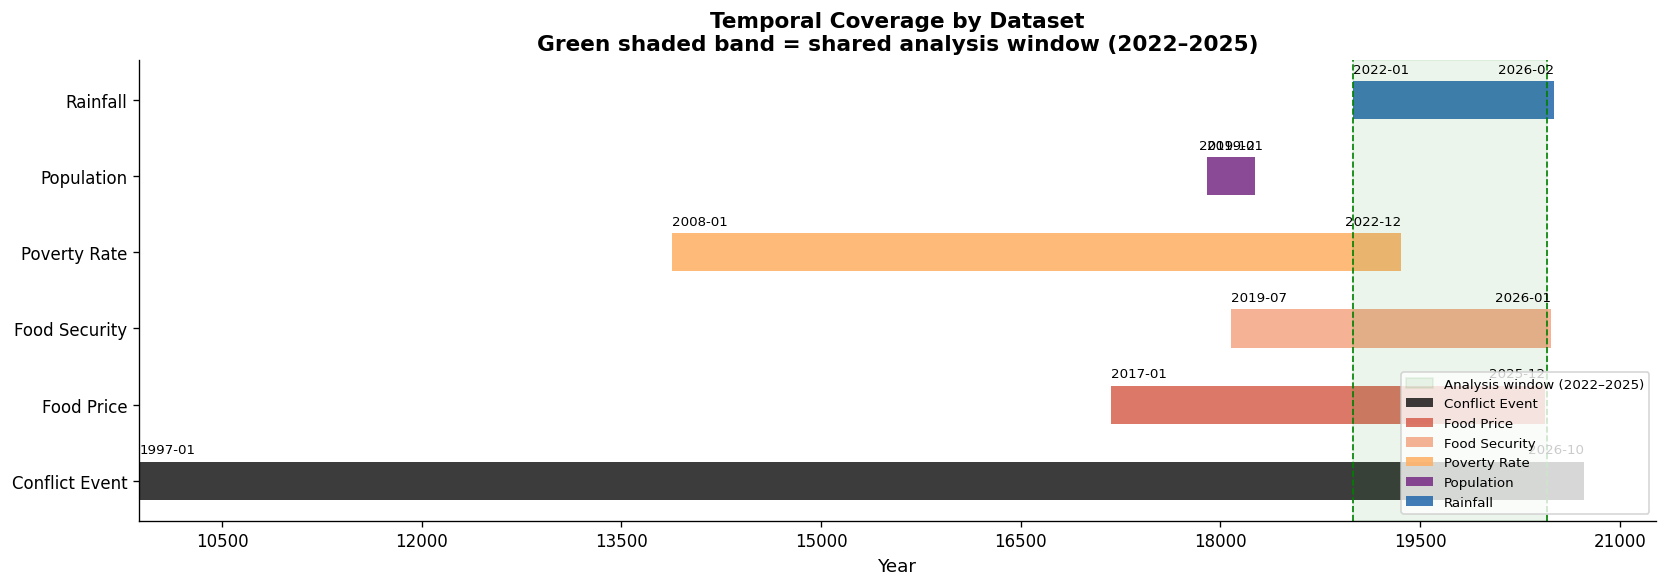

Saved: outputs/figures/01_temporal_coverage.png


In [10]:
# Temporal coverage timeline chart 
fig, ax = plt.subplots(figsize=(14, 5))

dataset_order = [
    'conflict_event', 'food_price', 'food_security',
    'poverty_rate', 'population', 'rainfall'
]

colour_map = {
    'rainfall':      COLOURS['rainfall'],
    'food_price':    COLOURS['food_price'],
    'conflict_event':      COLOURS['conflict'],
    'food_security': COLOURS['food_security'],
    'population':    COLOURS['poverty'],
    'poverty_rate':       COLOURS['highlight'],
}

for idx, name in enumerate(dataset_order):
    df = DATASETS[name]
    start = df['reference_period_start'].min()
    end   = df['reference_period_end'].max()

    ax.barh(
        y=idx,
        width=(end - start).days,
        left=start,
        height=0.5,
        color=colour_map[name],
        alpha=0.85,
        label=name.replace('_', ' ').title()
    )

    # Annotate with exact date range
    ax.text(
        start, idx + 0.32,
        f"{start.strftime('%Y-%m')}",
        fontsize=8, va='bottom'
    )
    ax.text(
        end, idx + 0.32,
        f"{end.strftime('%Y-%m')}",
        fontsize=8, va='bottom', ha='right'
    )

# Mark the analysis overlap window
overlap_start = pd.Timestamp('2022-01-01')
overlap_end   = pd.Timestamp('2025-12-31')
ax.axvspan(
    overlap_start, overlap_end,
    alpha=0.08, color='green', label='Analysis window (2022–2025)'
)
ax.axvline(overlap_start, color='green', linestyle='--', linewidth=1)
ax.axvline(overlap_end,   color='green', linestyle='--', linewidth=1)

ax.set_yticks(range(len(dataset_order)))
ax.set_yticklabels(
    [d.replace('_', ' ').title() for d in dataset_order],
    fontsize=10
)
ax.set_xlabel('Year', fontsize=11)
ax.set_title(
    'Temporal Coverage by Dataset\n'
    'Green shaded band = shared analysis window (2022–2025)',
    fontweight='bold'
)
ax.legend(loc='lower right', fontsize=8)
ax.xaxis.set_major_locator(mticker.MaxNLocator(10))
plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, '01_temporal_coverage.png'),
    bbox_inches='tight', dpi=150
)
plt.show()
print("Saved: outputs/figures/01_temporal_coverage.png")

## 5. Geographic Coverage

Kenya has 47 counties. Not every dataset covers all 47.  
We need to know the county overlap to define our analysis scope.

In [20]:
# County coverage per dataset 

rain_counties  = set(DATASETS['rainfall'][DATASETS['rainfall']['admin_level']==2]['admin1_name'].dropna().unique())
price_counties = set(DATASETS['food_price']['admin1_name'].dropna().unique())
fs_counties    = set(DATASETS['food_security']['admin1_name'].dropna().unique())
pov_counties   = set(DATASETS['poverty_rate']['admin1_name'].dropna().unique())
pop_counties   = set(DATASETS['population']['admin1_name'].dropna().unique())
conf_counties  = set(DATASETS['conflict_event']['ADMIN1'].dropna().unique())

coverage = {
    'Rainfall (admin2)':   rain_counties,
    'Food Price':          price_counties,
    'Food Security (IPC)': fs_counties,
    'Poverty Rate':        pov_counties,
    'Population':          pop_counties,
    'Conflict':            conf_counties,
}

print("County Coverage Per Dataset")
print(" ")
for name, counties in coverage.items():
    n = len(counties)
    bar = '█' * n + '░' * (47 - n)
    print(f"{name:<22} {n:>2}/47  {bar}")

County Coverage Per Dataset
 
Rainfall (admin2)      47/47  ███████████████████████████████████████████████
Food Price             24/47  ████████████████████████░░░░░░░░░░░░░░░░░░░░░░░
Food Security (IPC)    28/47  ████████████████████████████░░░░░░░░░░░░░░░░░░░
Poverty Rate           47/47  ███████████████████████████████████████████████
Population             47/47  ███████████████████████████████████████████████
Conflict               47/47  ███████████████████████████████████████████████


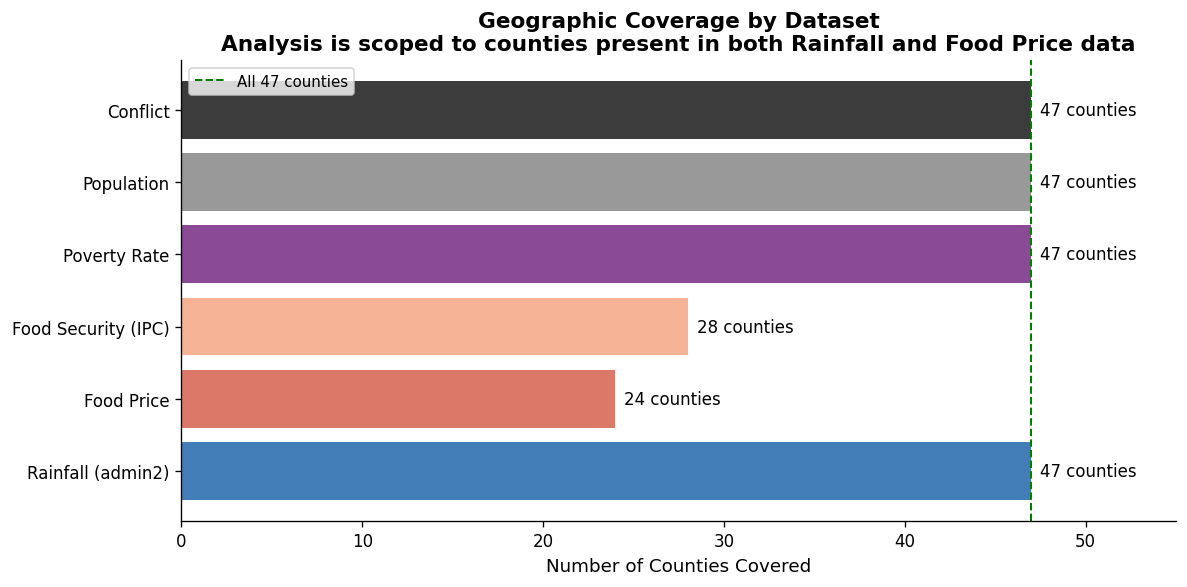

Saved: outputs/figures/01_geographic_coverage.png


In [22]:
# County coverage bar chart
dataset_names  = list(coverage.keys())
dataset_counts = [len(v) for v in coverage.values()]
bar_colours    = [
    COLOURS['rainfall'], COLOURS['food_price'], COLOURS['food_security'],
    COLOURS['poverty'],  COLOURS['neutral'],    COLOURS['conflict']
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(dataset_names, dataset_counts, color=bar_colours, alpha=0.85)

# Add 47-county reference line
ax.axvline(47, color='green', linestyle='--', linewidth=1.2, label='All 47 counties')

# Annotate count on each bar
for bar, count in zip(bars, dataset_counts):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{count} counties',
        va='center', fontsize=10
    )

ax.set_xlim(0, 55)
ax.set_xlabel('Number of Counties Covered', fontsize=11)
ax.set_title(
    'Geographic Coverage by Dataset\n'
    'Analysis is scoped to counties present in both Rainfall and Food Price data',
    fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, '01_geographic_coverage.png'),
    bbox_inches='tight', dpi=150
)
plt.show()
print("Saved: outputs/figures/01_geographic_coverage.png")

## 6. Poverty Stratification - Identifying Vulnerable Counties

The poverty dataset is a survey (static), not a time series.  
We use it to classify all 47 counties into vulnerability tiers.  
These tiers will stratify all subsequent analysis:  
the cascade effect should be strongest in the highest-vulnerability counties.

In [26]:
# Classify counties into vulnerability tiers using MPI 
# MPI = Multidimensional Poverty Index (0 to 1; higher = more deprived)
# Source: Oxford Poverty & Human Development Initiative (OPHI)

# Use most recent MPI value per county (some counties have multiple survey years)
poverty_latest = (
    DATASETS['poverty_rate']
    .sort_values('reference_period_start', ascending=False)
    .dropna(subset=['admin1_name', 'mpi'])
    .drop_duplicates(subset='admin1_name', keep='first')
    [['admin1_name', 'mpi', 'headcount_ratio', 'in_severe_poverty']]
    .copy()
)

# Define vulnerability tiers
# Thresholds based on Kenya's national MPI distribution
def assign_tier(mpi):
    if mpi >= 0.30:
        return 'High'      # Chronically deprived — ASAL counties
    elif mpi >= 0.15:
        return 'Medium'    # Moderate deprivation
    else:
        return 'Low'       # Relatively better off

poverty_latest['vulnerability_tier'] = poverty_latest['mpi'].apply(assign_tier)

# Summary
tier_counts = poverty_latest['vulnerability_tier'].value_counts()
print("Vulnerability Tier Distribution")
print(" ")
for tier in ['High', 'Medium', 'Low']:
    n = tier_counts.get(tier, 0)
    print(f"{tier:<10} {n:>2} counties")

print()
print("High vulnerability counties (MPI ≥ 0.30):")
high_vuln = poverty_latest[poverty_latest['vulnerability_tier']=='High']
print(high_vuln[['admin1_name','mpi','headcount_ratio']]
      .sort_values('mpi', ascending=False)
      .to_string(index=False))

Vulnerability Tier Distribution
 
High        7 counties
Medium      8 counties
Low        32 counties

High vulnerability counties (MPI ≥ 0.30):
admin1_name  mpi  headcount_ratio
    Turkana 0.50            79.55
    Mandera 0.46            81.34
    Samburu 0.42            70.16
      Wajir 0.40            73.11
 Tana River 0.38            67.29
 West Pokot 0.35            65.79
   Marsabit 0.35            63.56


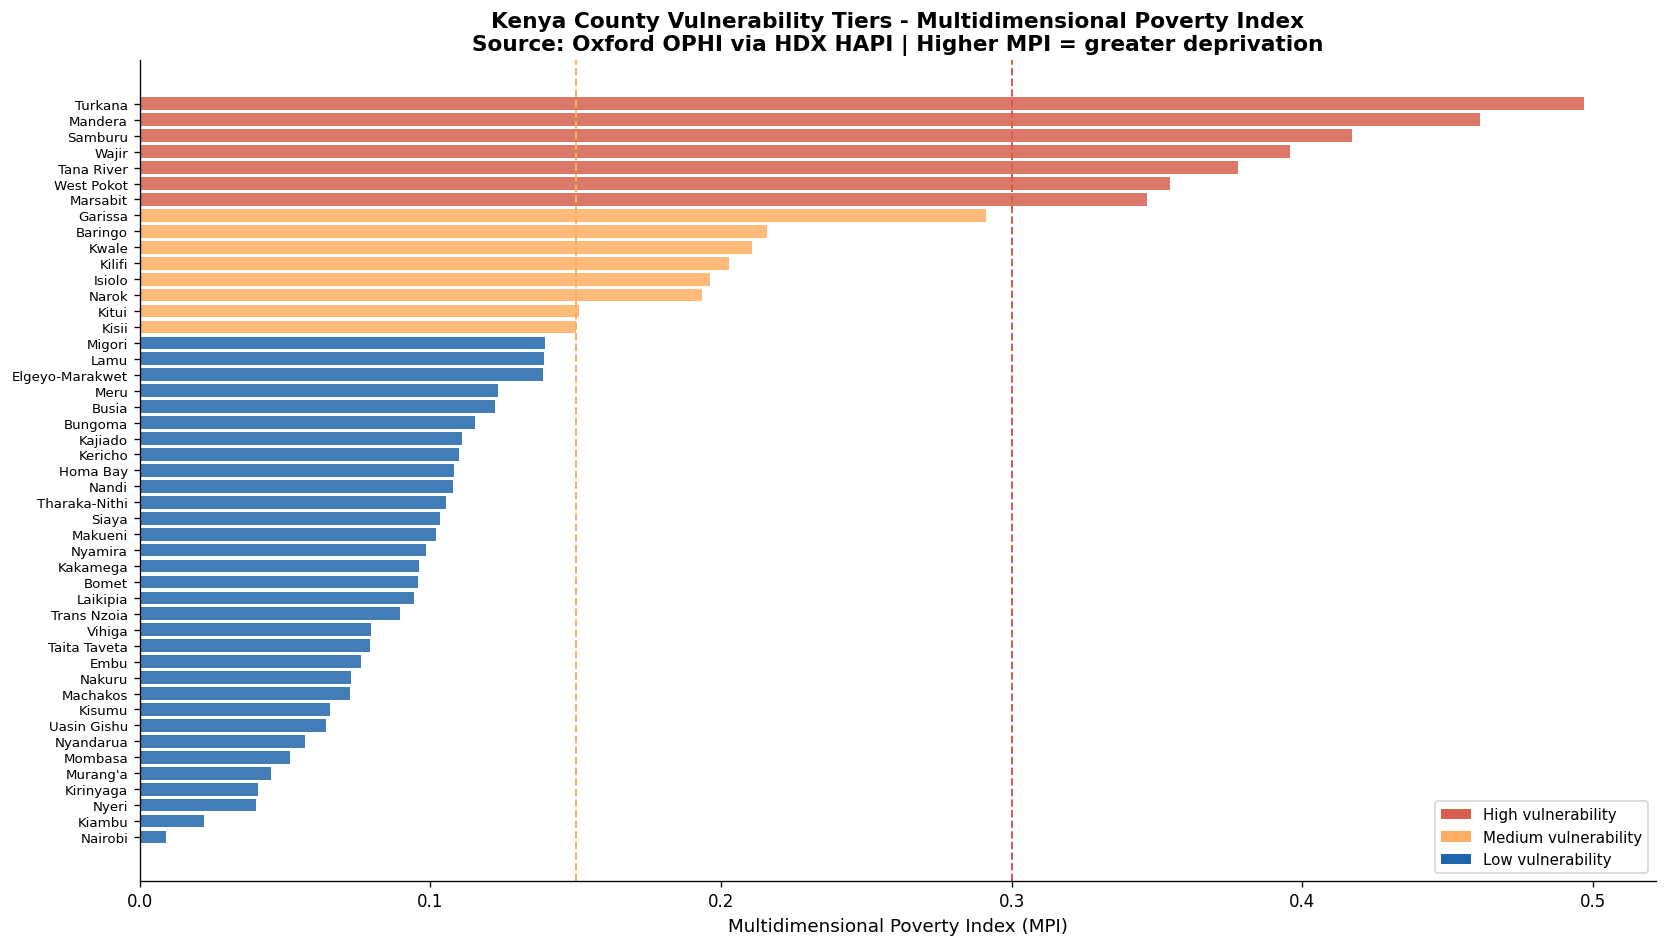

Saved: outputs/figures/01_poverty_vulnerability_tiers.png


In [28]:
# MPI distribution chart
poverty_plot = poverty_latest.sort_values('mpi', ascending=True).copy()

tier_colour_map = {
    'High':   COLOURS['food_price'],
    'Medium': COLOURS['highlight'],
    'Low':    COLOURS['rainfall'],
}
bar_cols = poverty_plot['vulnerability_tier'].map(tier_colour_map)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(
    poverty_plot['admin1_name'],
    poverty_plot['mpi'],
    color=bar_cols,
    alpha=0.85
)

# Tier threshold lines
ax.axvline(0.30, color=COLOURS['food_price'], linestyle='--',
           linewidth=1.2, label='High threshold (MPI = 0.30)')
ax.axvline(0.15, color=COLOURS['highlight'],  linestyle='--',
           linewidth=1.2, label='Medium threshold (MPI = 0.15)')

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOURS['food_price'], label='High vulnerability'),
    Patch(facecolor=COLOURS['highlight'],  label='Medium vulnerability'),
    Patch(facecolor=COLOURS['rainfall'],   label='Low vulnerability'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

ax.set_xlabel('Multidimensional Poverty Index (MPI)', fontsize=11)
ax.set_title(
    'Kenya County Vulnerability Tiers - Multidimensional Poverty Index\n'
    'Source: Oxford OPHI via HDX HAPI | Higher MPI = greater deprivation',
    fontweight='bold'
)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, '01_poverty_vulnerability_tiers.png'),
    bbox_inches='tight', dpi=150
)
plt.show()
print("Saved: outputs/figures/01_poverty_vulnerability_tiers.png")

## 7. Rainfall Anomaly Overview

Before we use `rainfall_anomaly_pct` as our primary climate shock indicator,  
we confirm it is plausible - the values should centre around 100%  
(100% = exactly average), with deficits below and surpluses above.

In [30]:
# Rainfall anomaly distribution 
# Filter to monthly aggregation at admin2 level (our working grain)
rain_monthly = DATASETS['rainfall'][
    (DATASETS['rainfall']['admin_level'] == 2) &
    (DATASETS['rainfall']['aggregation_period'] == '1-month')
].copy()

print("Rainfall Anomaly Summary (monthly, admin2)")
print(" " )
stats = rain_monthly['rainfall_anomaly_pct'].describe()
print(stats.round(1))

print()
# What fraction of county-months show a deficit (below 80% of average)?
deficit_pct = (rain_monthly['rainfall_anomaly_pct'] < 80).mean() * 100
surplus_pct = (rain_monthly['rainfall_anomaly_pct'] > 120).mean() * 100
print(f"County-months with deficit (< 80%):  {deficit_pct:.1f}%")
print(f"County-months with surplus (> 120%): {surplus_pct:.1f}%")

Rainfall Anomaly Summary (monthly, admin2)
 
count   2628.00
mean     106.00
std       44.00
min       18.50
25%       75.90
50%      102.90
75%      132.90
max      377.10
Name: rainfall_anomaly_pct, dtype: float64

County-months with deficit (< 80%):  28.0%
County-months with surplus (> 120%): 34.7%


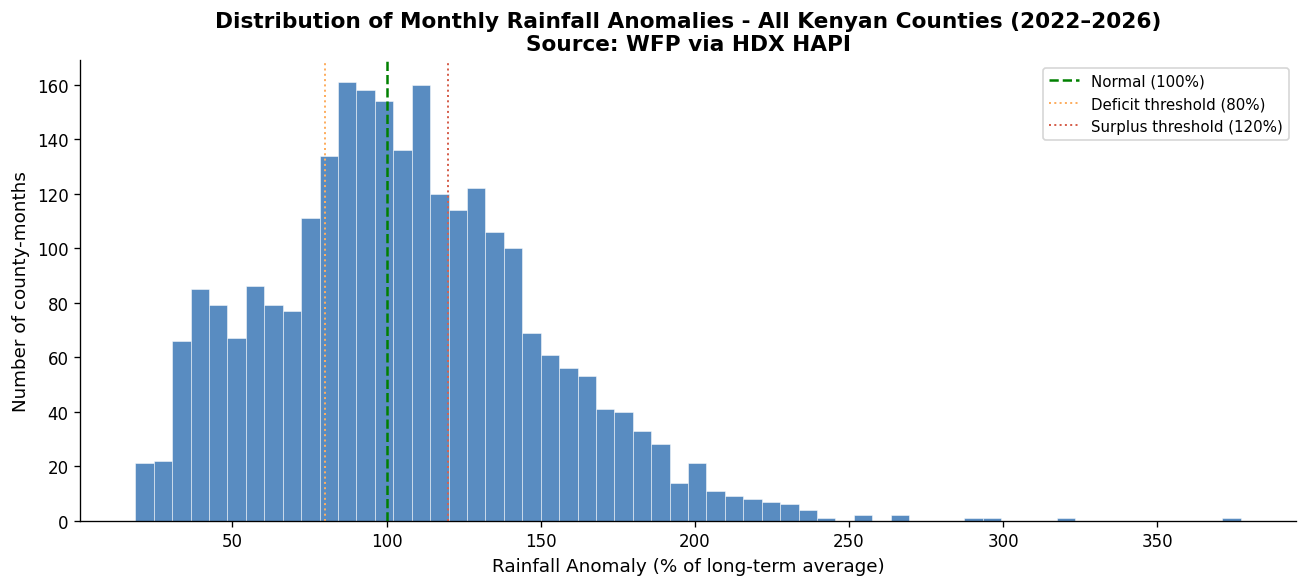

Saved: outputs/figures/01_rainfall_anomaly_distribution.png


In [32]:
# Rainfall anomaly histogram
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(
    rain_monthly['rainfall_anomaly_pct'],
    bins=60,
    color=COLOURS['rainfall'],
    alpha=0.75,
    edgecolor='white',
    linewidth=0.4
)

# Reference lines
ax.axvline(100,  color='green',              linestyle='--', linewidth=1.5, label='Normal (100%)')
ax.axvline(80,   color=COLOURS['highlight'], linestyle=':',  linewidth=1.2, label='Deficit threshold (80%)')
ax.axvline(120,  color=COLOURS['food_price'],linestyle=':',  linewidth=1.2, label='Surplus threshold (120%)')

ax.set_xlabel('Rainfall Anomaly (% of long-term average)', fontsize=11)
ax.set_ylabel('Number of county-months', fontsize=11)
ax.set_title(
    'Distribution of Monthly Rainfall Anomalies - All Kenyan Counties (2022–2026)\n'
    'Source: WFP via HDX HAPI',
    fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, '01_rainfall_anomaly_distribution.png'),
    bbox_inches='tight', dpi=150
)
plt.show()
print("Saved: outputs/figures/01_rainfall_anomaly_distribution.png")